In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PLOT_SETTINGS = {
    'font_size': 15,
    'font_family': 'Arial',
    'dpi': 600,
    'linewidth': 2.5,
    'marker_size': 8,
    'error_capsize': 3,
    'colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22'],
    'markers': ['o-', 's-', '^-', 'D-', 'v-', '<-', '>-', 'p-'],
    'title_size': 17,
    'label_size': 16,
    'tick_size': 14,
    'legend_size': 12,
    'grid': False,
    'alpha': 0.8,
    'fitted_line_style': '--',
    'fitted_line_alpha': 0.7,

}
settings = PLOT_SETTINGS
plt.rcParams.update({
    'font.size': settings['font_size'],
    'font.family': settings['font_family'],
    'axes.titlesize': settings['title_size'],
    'axes.labelsize': settings['label_size'],
    'xtick.labelsize': settings['tick_size'],
    'ytick.labelsize': settings['tick_size'],
    'legend.fontsize': settings['legend_size'],
    'figure.dpi': settings['dpi'],
    'lines.linewidth': settings['linewidth'],
    'axes.grid': settings['grid'],
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.linewidth': 0.8,
})


In [11]:
def amplification_function(s, n, k):
    """Return f(s) = n * s^{n-1} / (1 + s^n)^2"""
    return (n/k) * (((s/k) ** (n - 1)) / (1 + (s/k) ** n) ** 2)

C:\Users\kra.valeriia\AppData\Local\Temp\ipykernel_31448\522153357.py:28: RuntimeWarning: divide by zero encountered in log10
  log_x = np.log10(x)


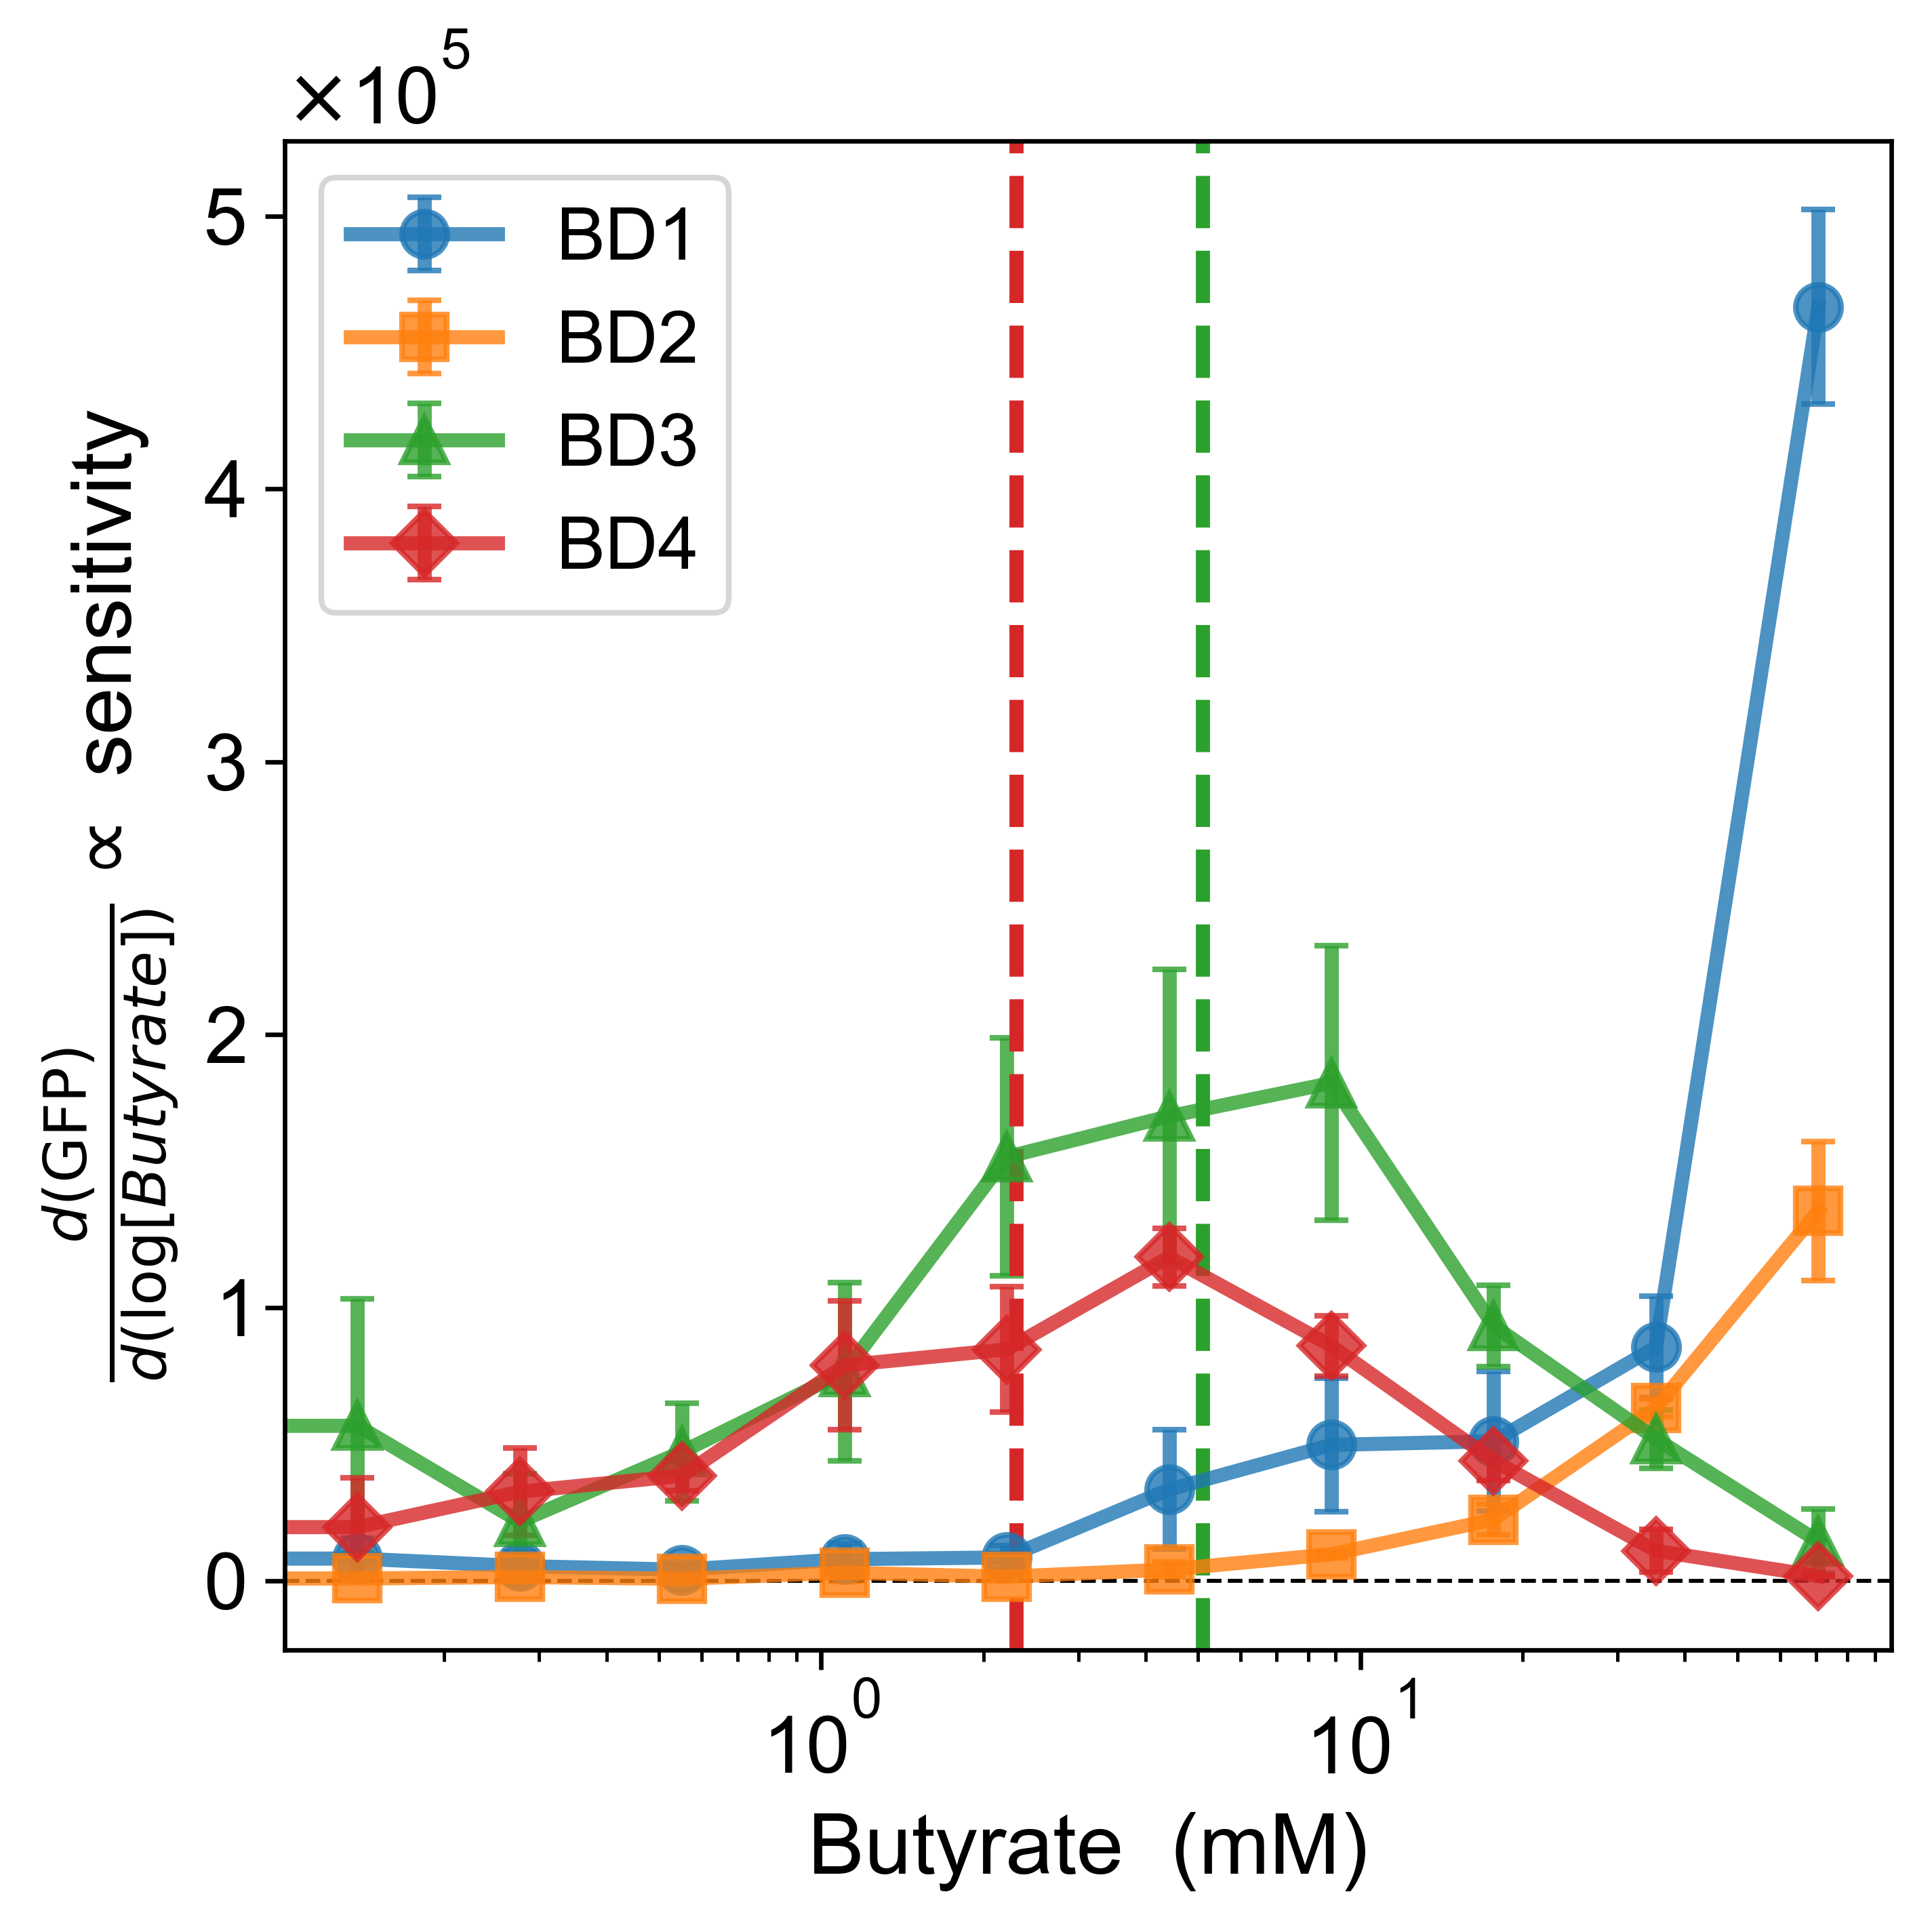

In [12]:
FILE  = "FACS_summary.xlsx"
SHEET = "Butyrate"   # or "Heme", "Lactate"

raw = pd.read_excel(FILE, sheet_name=SHEET, header=None)

sensor_names   = raw.iloc[0, 2:].values                                    # row 0: design labels
concentrations = pd.to_numeric(raw.iloc[1:, 1], errors='coerce').values    # col 1: concentrations
data_block     = raw.iloc[1:, 2:].apply(pd.to_numeric, errors='coerce').values

unique_sensors = list(dict.fromkeys(sensor_names))
colors = settings['colors'][:len(unique_sensors)]

fig, ax = plt.subplots(figsize=(5, 5))

for sensor, color in zip(unique_sensors, colors):
    rep_cols = data_block[:, sensor_names == sensor].astype(float)   #  (n_conc, n_reps)
    valid = ~np.isnan(concentrations)
    x    = concentrations[valid]
    reps = rep_cols[valid, :]
    idx  = np.argsort(x)
    x    = x[idx]
    reps = reps[idx, :]
    col_min = np.nanmin(reps, axis=0)
    col_max = np.nanmax(reps, axis=0)
    reps_norm = (reps - col_min) / (col_max - col_min)

    # empirical sensitivity per replicate: Δy / Δlog10(x) based on raw data (not normalised or normalized)
    log_x = np.log10(x)
    # finite difference between adjacent points
    # sens_reps = abs(np.diff(reps_norm, axis=0) / np.diff(log_x)[:, None])
    sens_reps = abs(np.diff(reps, axis=0) / np.diff(log_x)[:, None])
    x_mid = 10 ** ((log_x[:-1] + log_x[1:]) / 2)
    sens_mean = np.nanmean(sens_reps, axis=1)
    sens_std  = np.nanstd(sens_reps, axis=1, ddof=1)
    marker = settings['markers'][unique_sensors.index(sensor) % len(settings['markers'])]
    ax.errorbar(x_mid, sens_mean, yerr=sens_std,  label=sensor,fmt=marker, color=color,
                        capsize=PLOT_SETTINGS['error_capsize'],
                        alpha=PLOT_SETTINGS['alpha'],
                        markersize=PLOT_SETTINGS['marker_size'],
                        linewidth=PLOT_SETTINGS['linewidth'])

from matplotlib.ticker import ScalarFormatter

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.axvline(5.1, color=colors[2], linewidth=2.5, linestyle='--')
ax.axvline(2.3, color=colors[3], linewidth=2.5, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel(f'{SHEET}  (mM)')
ax.set_ylabel(rf'$\frac{{d(\mathrm{{GFP}})}}{{d(\log[{SHEET}])}} \propto$ sensitivity')
ax.legend(fontsize=13)
plt.tight_layout()
plt.savefig(f"sensitivity_empirical_{SHEET}.png", bbox_inches='tight', dpi = 600)
plt.show()

C:\Users\kra.valeriia\AppData\Local\Temp\ipykernel_31448\2350713621.py:28: RuntimeWarning: divide by zero encountered in log10
  log_x = np.log10(x)
C:\Users\kra.valeriia\AppData\Local\Temp\ipykernel_31448\2350713621.py:33: RuntimeWarning: Mean of empty slice
  sens_mean = np.nanmean(sens_reps, axis=1)
C:\Users\kra.valeriia\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


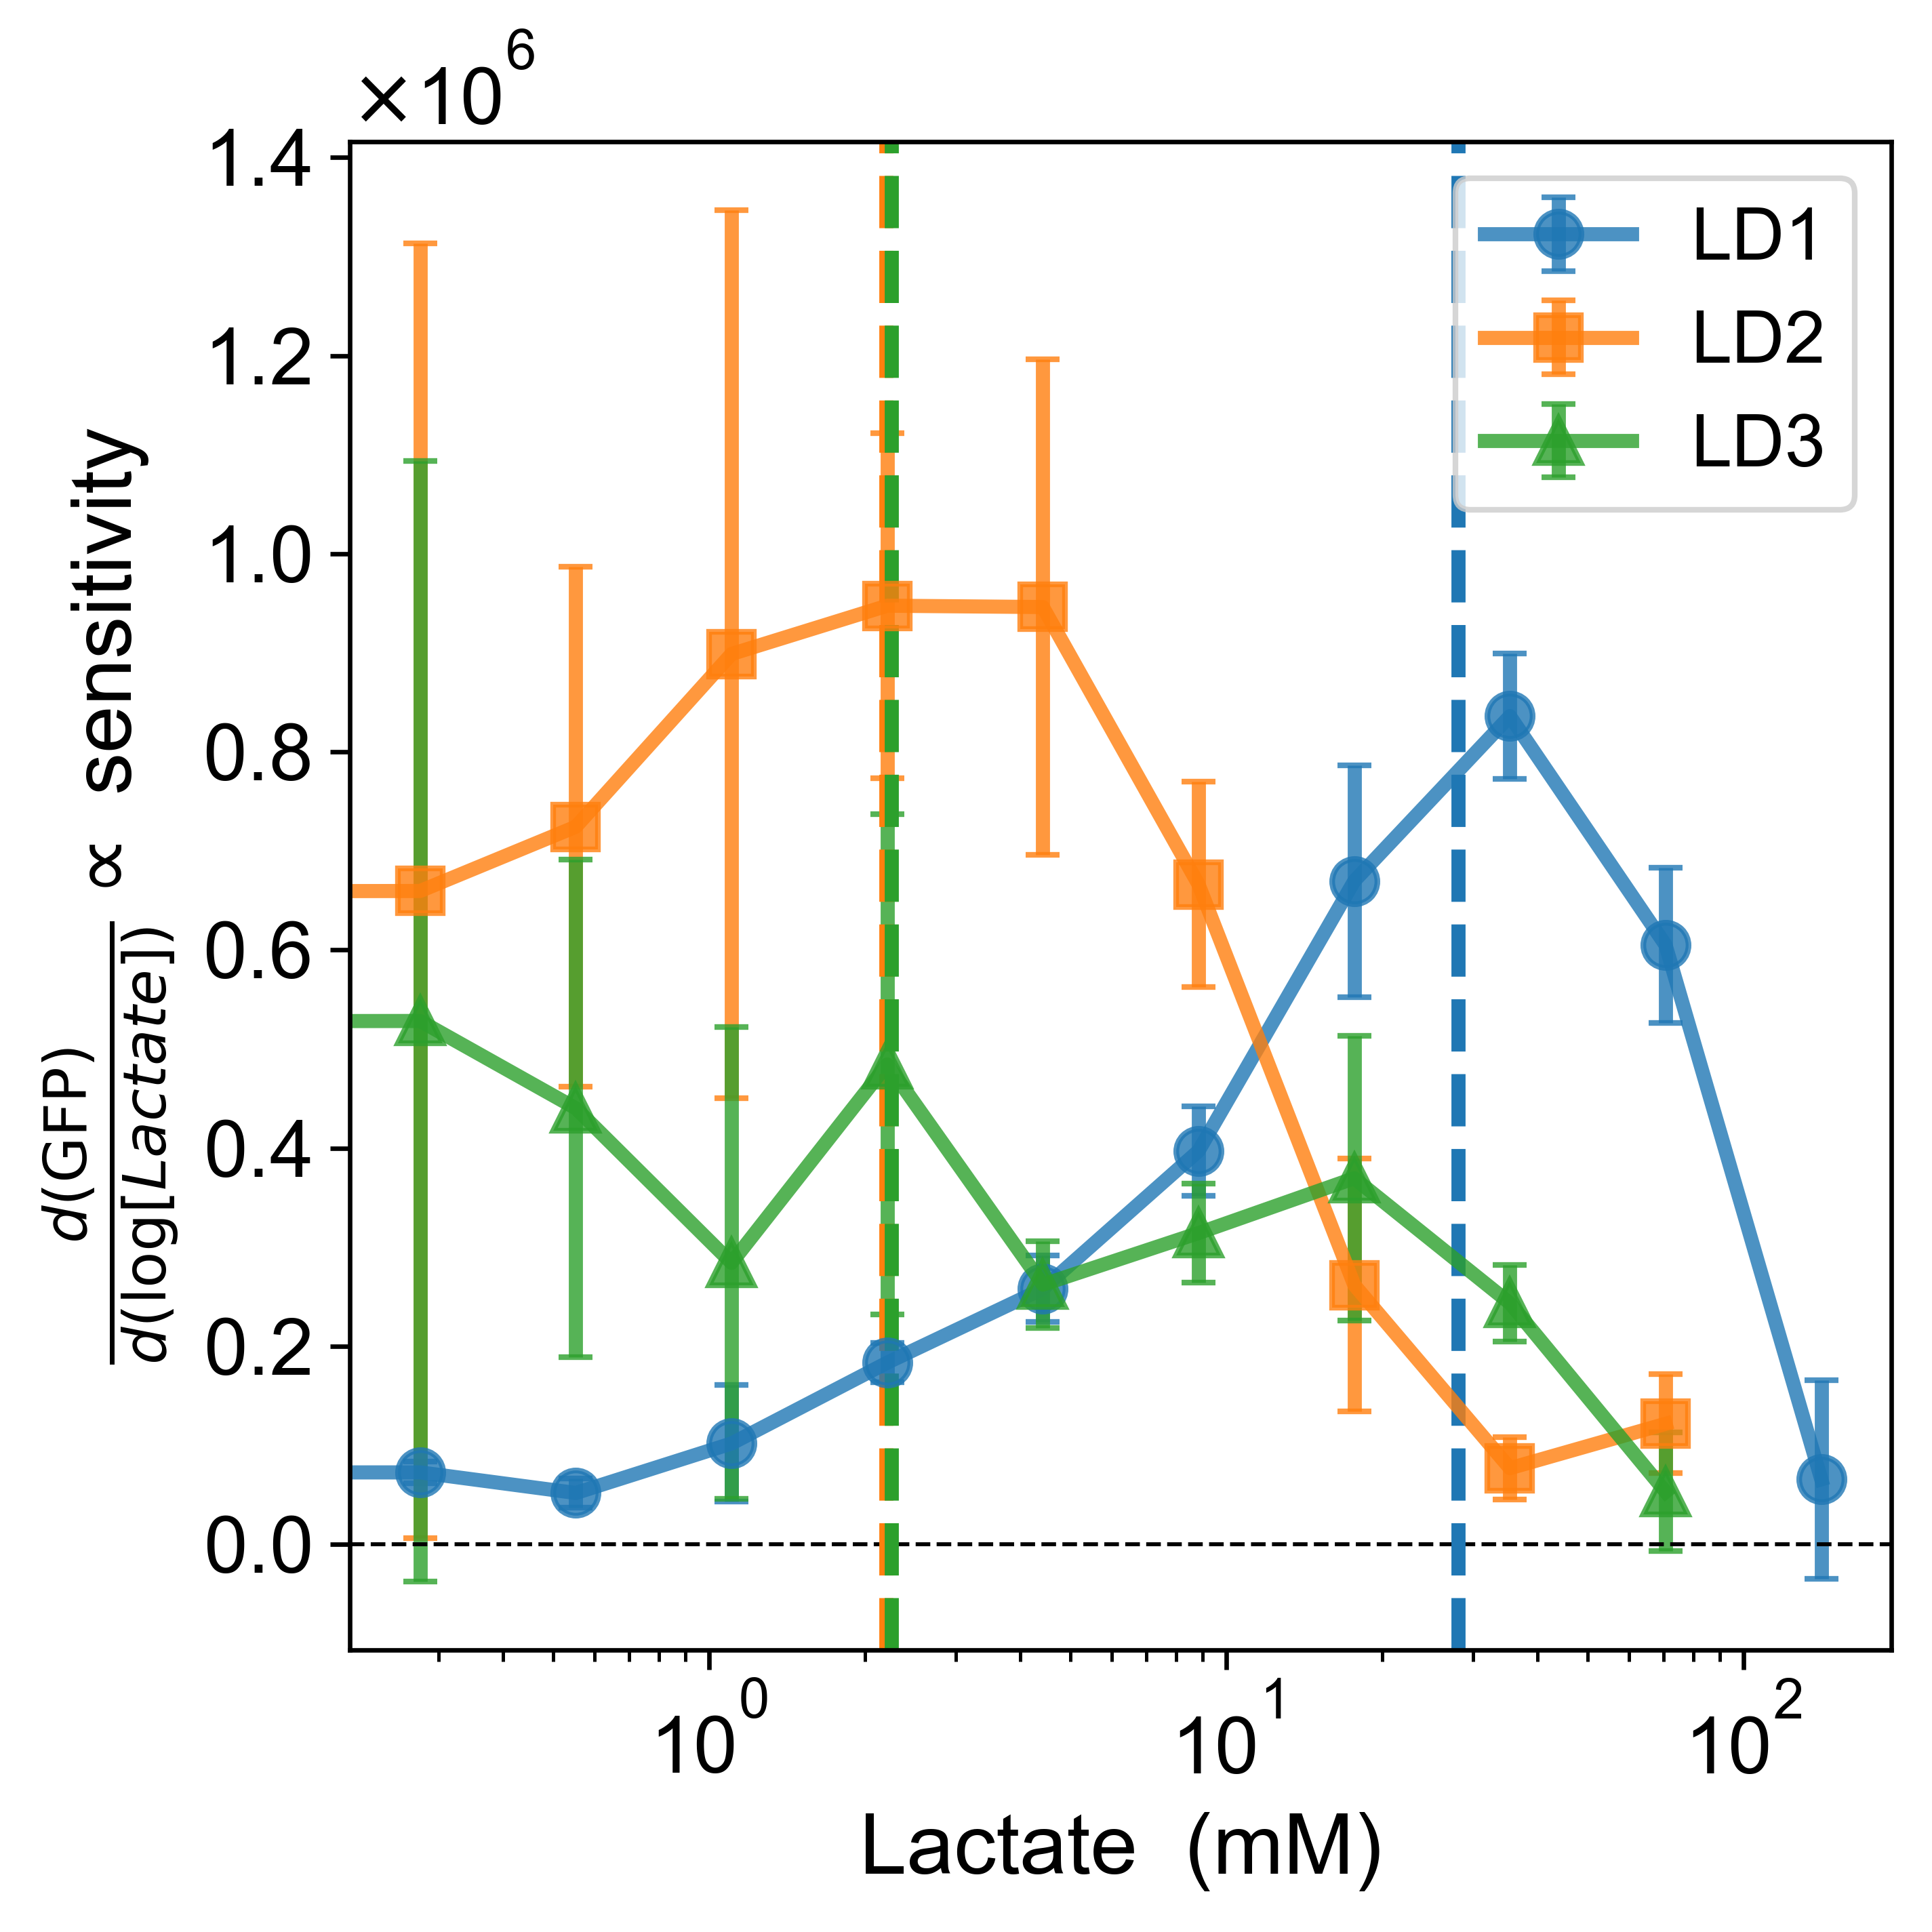

In [13]:
FILE  = "FACS_summary.xlsx"
SHEET = "Lactate"   # or "Heme", "Lactate"

raw = pd.read_excel(FILE, sheet_name=SHEET, header=None)

sensor_names   = raw.iloc[0, 2:].values                                    # row 0: design labels
concentrations = pd.to_numeric(raw.iloc[1:, 1], errors='coerce').values    # col 1: concentrations
data_block     = raw.iloc[1:, 2:].apply(pd.to_numeric, errors='coerce').values

unique_sensors = list(dict.fromkeys(sensor_names))
colors = settings['colors'][:len(unique_sensors)]

fig, ax = plt.subplots(figsize=(5, 5))

for sensor, color in zip(unique_sensors, colors):
    if sensor == "LD4":  # skip LD4 due to outlier issues
        continue
    rep_cols = data_block[:, sensor_names == sensor].astype(float)
    valid = ~np.isnan(concentrations)
    x    = concentrations[valid]
    reps = rep_cols[valid, :]
    idx  = np.argsort(x)
    x    = x[idx]
    reps = reps[idx, :]
    col_min = np.nanmin(reps, axis=0)
    col_max = np.nanmax(reps, axis=0)
    reps_norm = (reps - col_min) / (col_max - col_min)
    log_x = np.log10(x)
    # finite difference between adjacent points
    # sens_reps = abs(np.diff(reps_norm, axis=0) / np.diff(log_x)[:, None])
    sens_reps = abs(np.diff(reps, axis=0) / np.diff(log_x)[:, None])
    x_mid = 10 ** ((log_x[:-1] + log_x[1:]) / 2)
    sens_mean = np.nanmean(sens_reps, axis=1)
    sens_std  = np.nanstd(sens_reps, axis=1, ddof=1)
    marker = settings['markers'][unique_sensors.index(sensor) % len(settings['markers'])]
    ax.errorbar(x_mid, sens_mean, yerr=sens_std,  label=sensor,fmt=marker, color=color,
                        capsize=PLOT_SETTINGS['error_capsize'],
                        alpha=PLOT_SETTINGS['alpha'],
                        markersize=PLOT_SETTINGS['marker_size'],
                        linewidth=PLOT_SETTINGS['linewidth'])

from matplotlib.ticker import ScalarFormatter

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.axvline(28.1, color=colors[0], linewidth=2.5, linestyle='--')
ax.axvline(2.2, color=colors[1], linewidth=2.5, linestyle='--')
ax.axvline(2.25, color=colors[2], linewidth=2.5, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel(f'{SHEET}  (mM)')
ax.set_ylabel(rf'$\frac{{d(\mathrm{{GFP}})}}{{d(\log[{SHEET}])}} \propto$ sensitivity')
ax.legend(fontsize=13)
plt.tight_layout()
plt.savefig(f"sensitivity_empirical_{SHEET}.png", bbox_inches='tight',dpi=600)
plt.show()

C:\Users\kra.valeriia\AppData\Local\Temp\ipykernel_31448\2936953923.py:29: RuntimeWarning: divide by zero encountered in log10
  log_x = np.log10(x)
C:\Users\kra.valeriia\AppData\Local\Temp\ipykernel_31448\2936953923.py:34: RuntimeWarning: Mean of empty slice
  sens_mean = np.nanmean(sens_reps, axis=1)
C:\Users\kra.valeriia\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


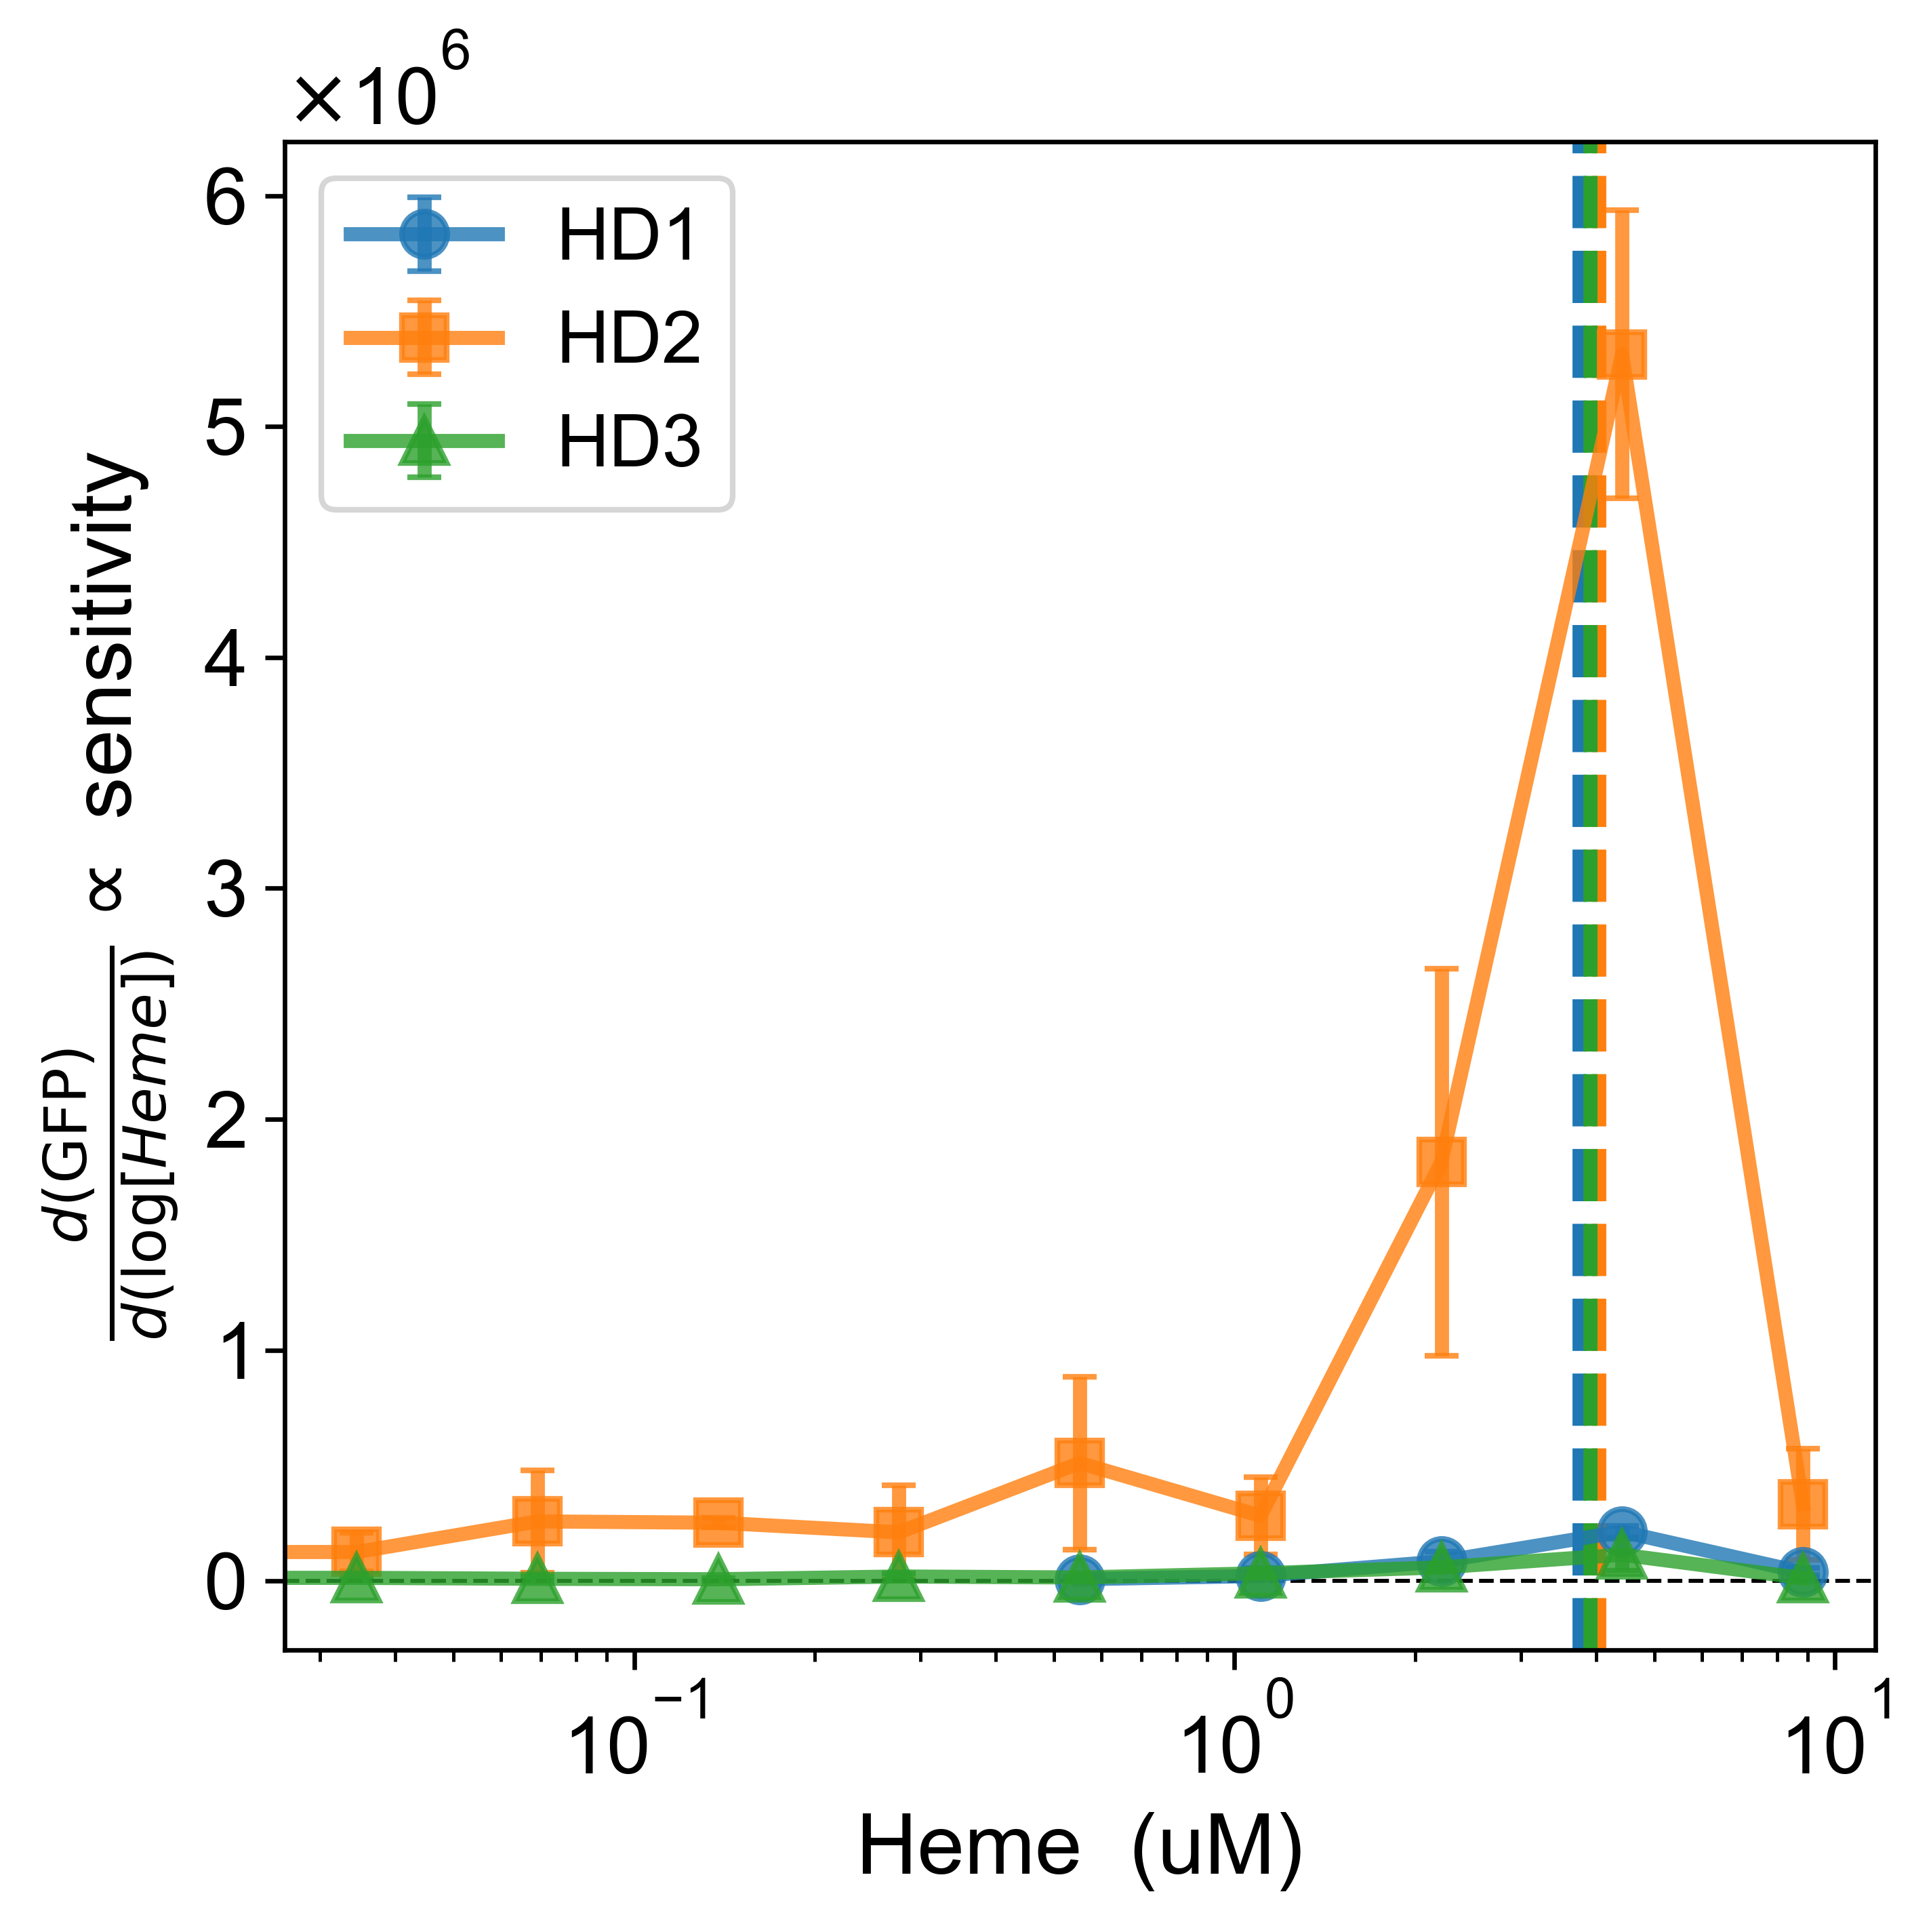

In [14]:
FILE  = "FACS_summary.xlsx"
SHEET = "Heme"   # or "Heme", "Lactate"

raw = pd.read_excel(FILE, sheet_name=SHEET, header=None)

sensor_names   = raw.iloc[0, 2:].values                                    # row 0: design labels
concentrations = pd.to_numeric(raw.iloc[1:, 1], errors='coerce').values    # col 1: concentrations
data_block     = raw.iloc[1:, 2:].apply(pd.to_numeric, errors='coerce').values

unique_sensors = list(dict.fromkeys(sensor_names))
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(unique_sensors)))
colors = settings['colors'][:len(unique_sensors)]

fig, ax = plt.subplots(figsize=(5, 5))

for sensor, color in zip(unique_sensors, colors):
    if sensor == "HD4":
        continue
    rep_cols = data_block[:, sensor_names == sensor].astype(float)   # (n_conc, n_reps)
    valid = ~np.isnan(concentrations)
    x    = concentrations[valid]
    reps = rep_cols[valid, :]
    idx  = np.argsort(x)
    x    = x[idx]
    reps = reps[idx, :]
    col_min = np.nanmin(reps, axis=0)
    col_max = np.nanmax(reps, axis=0)
    reps_norm = (reps - col_min) / (col_max - col_min)   # (n_conc, n_reps)
    log_x = np.log10(x)
    # finite difference between adjacent points
    # sens_reps = abs(np.diff(reps_norm, axis=0) / np.diff(log_x)[:, None])
    sens_reps = abs(np.diff(reps, axis=0) / np.diff(log_x)[:, None])
    x_mid = 10 ** ((log_x[:-1] + log_x[1:]) / 2)
    sens_mean = np.nanmean(sens_reps, axis=1)
    sens_std  = np.nanstd(sens_reps, axis=1, ddof=1)
    marker = settings['markers'][unique_sensors.index(sensor) % len(settings['markers'])]
    ax.errorbar(x_mid, sens_mean, yerr=sens_std,  label=sensor,fmt=marker, color=color,
                        capsize=PLOT_SETTINGS['error_capsize'],
                        alpha=PLOT_SETTINGS['alpha'],
                        markersize=PLOT_SETTINGS['marker_size'],
                        linewidth=PLOT_SETTINGS['linewidth'])

from matplotlib.ticker import ScalarFormatter

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.axvline(3.75, color=colors[0], linewidth=2.5, linestyle='--')
ax.axvline(4.04, color=colors[1], linewidth=2.5, linestyle='--')
ax.axvline(3.91, color=colors[2], linewidth=2.5, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel(f'{SHEET}  (uM)')
ax.set_ylabel(rf'$\frac{{d(\mathrm{{GFP}})}}{{d(\log[{SHEET}])}} \propto$ sensitivity')
ax.legend(fontsize=13)
plt.tight_layout()
plt.savefig(f"sensitivity_empirical_{SHEET}.png", bbox_inches='tight',dpi=600)
plt.show()